In [20]:
from cProfile import label

from IPython.core.pylabtools import figsize
from matplotlib.pyplot import tight_layout
%matplotlib inline

In [21]:
import sqlite3
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [22]:
conn = sqlite3.connect('oscars.db')

In [23]:
pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table'", conn)

,name
0,stg_oscars
1,ceremony
2,film
3,category
4,sqlite_sequence
5,nominee
6,nomination
7,participation
8,dim_ceremony
9,dim_category


In [26]:
#Gráfico 1 — Q3: Top 10 filmes mais nomeados (horizontal bar chart)

q3 = pd.read_sql_query("""
    SELECT df.title, COUNT(*) AS nominations
    FROM fact_nomination fn
    JOIN dim_film df ON fn.film_key = df.film_key
    WHERE df.title IS NOT NULL
    GROUP BY df.title
    ORDER BY nominations DESC
    LIMIT 10;
""", conn)

q3

,title,nominations
0,A Star Is Born,26
1,West Side Story,18
2,Titanic,16
3,Mutiny on the Bounty,15
4,Moulin Rouge,15
5,Gone with the Wind,15
6,Little Women,14
7,La La Land,14
8,Cleopatra,14
9,All about Eve,14


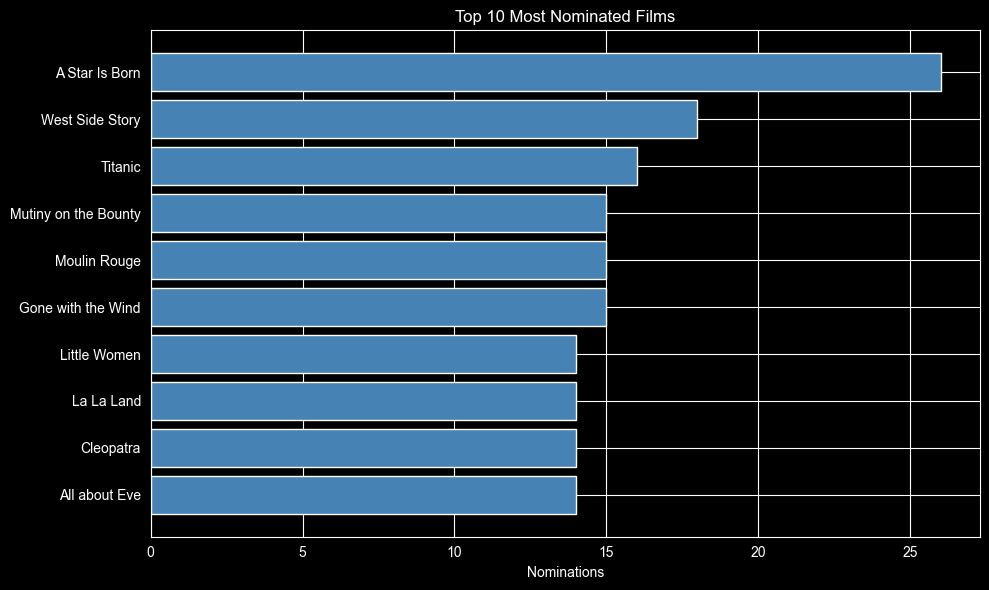

In [29]:
fig, ax = plt.subplots(figsize=(10,6))

ax.barh(q3['title'], q3['nominations'],color='steelblue') #desenha barras horizontais

ax.set_xlabel('Nominations')
ax.set_title('Top 10 Most Nominated Films')
ax.invert_yaxis()   #o filme com mais nomiações fica no topo (ordem decrescente)

plt.tight_layout()
plt.show()


In [34]:
#Gráfico 2 — Q9: Nominations by Decade (grouped bar chart)

q9 = pd.read_sql_query("""
      SELECT dcer.decade, COUNT(*) AS nominations, SUM(fn.win_count) AS wins
      FROM fact_nomination fn
      JOIN dim_ceremony dcer ON fn.ceremony_key = dcer.ceremony_key
      GROUP BY dcer.decade
      ORDER BY dcer.decade
  """, conn)

q9


,decade,nominations,wins
0,1920,133,33
1,1930,866,227
2,1940,1528,343
3,1950,1259,355
4,1960,1235,328
5,1970,1152,345
6,1980,1182,381
7,1990,1320,460
8,2000,1288,411
9,2010,1394,421


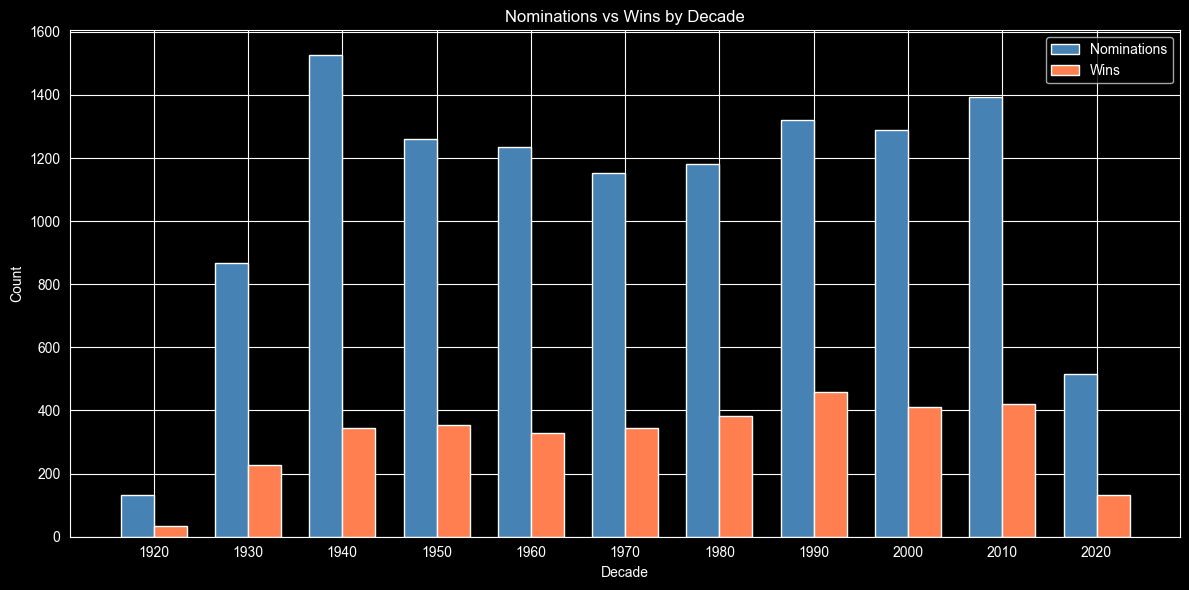

In [36]:
fig, ax = plt.subplots(figsize=(12,6))

x = range(len(q9))
width = 0.35

ax.bar(x, q9['nominations'], width, label = 'Nominations', color='steelblue')
ax.bar([i + width for i in x], q9['wins'], width, label='Wins', color='coral')

ax.set_xlabel('Decade')
ax.set_ylabel('Count')
ax.set_title('Nominations vs Wins by Decade')
ax.set_xticks([i + width / 2 for i in x])
ax.set_xticklabels(q9['decade'].astype(str))
ax.legend()

plt.tight_layout()
plt.show()

In [38]:
#Gráfico 3 — Q5: Wins por Ano (line plot)
q5 = pd.read_sql_query("""
      SELECT dcer.year, SUM(fn.win_count) AS wins
      FROM fact_nomination fn
      JOIN dim_ceremony dcer ON fn.ceremony_key = dcer.ceremony_key
      GROUP BY dcer.year
      ORDER BY dcer.year
""", conn)

q5

,year,wins
0,1927/28,18
1,1928/29,7
2,1929/30,8
3,1930/31,15
4,1931/32,16
...,...,...
91,2019,45
92,2020,25
93,2021,27
94,2022,36


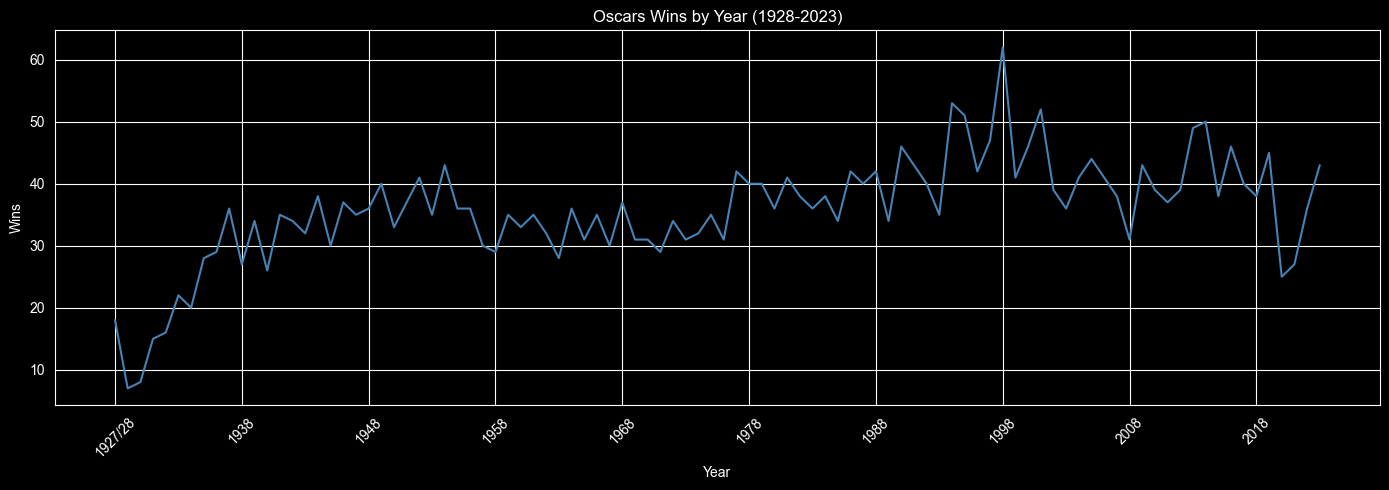

In [41]:
fig, ax = plt.subplots(figsize=(14,5))

ax.plot(q5['year'],q5['wins'],color='steelblue', linewidth=1.5)

ax.set_xlabel('Year')
ax.set_ylabel('Wins')
ax.set_title('Oscars Wins by Year (1928-2023)')
ax.set_xticks(range(0, len(q5), 10))
ax.set_xticklabels(q5['year'].iloc[::10], rotation=45)


plt.tight_layout()
plt.show()

Olhando para os dados da Q5:

  1. **Crescimento inicial (1928–1940s)** — O número de wins **sobe bastante**. A Academia estava a criar novas categorias
  (documentário, efeitos visuais, etc.), logo mais prémios por cerimónia.
  2. **Estabilização (1950s–1980s)** — Os valores mantêm-se relativamente estáveis. As categorias já estavam
  consolidadas.
  3. **Pico nos anos 90** — 1998 destaca-se com 62 wins (o ano do Titanic). Os anos 90 em geral têm valores altos,
  refletindo o auge da indústria pré-streaming.
  4. **Queda nos 2020s** — Valores mais baixos, possivelmente por causa da pandemia (cerimónias mais curtas, menos
  categorias ativas) e porque o dataset só vai até 2023.
  5. **Tendência geral** — De ~7-18 wins nos primeiros anos para ~25-50 nos recentes. O crescimento deve-se principalmente à expansão do número de categorias, não a mais winners por categoria.

  Em resumo: o gráfico mostra que a Academia foi crescendo ao longo das décadas, dando            cada vez mais prémios, com um pico nos anos 90 e uma ligeira retração recente.

In [45]:
# Gráfico 4 — Q8: Top 10 filmes mais nomeados com Win Rate (bar chart com dual axis)

q8 = pd.read_sql_query("""
      SELECT df.title, COUNT(*) AS nominations,
             SUM(fn.win_count) AS wins,
             ROUND(100.0 * SUM(fn.win_count) / COUNT(*), 1) AS win_rate_pct
      FROM fact_nomination fn
      JOIN dim_film df ON fn.film_key = df.film_key
      WHERE df.title IS NOT NULL
      GROUP BY df.title
      HAVING nominations >= 3
      ORDER BY nominations DESC
      LIMIT 10
""", conn)

q8

,title,nominations,wins,win_rate_pct
0,A Star Is Born,26,4,15.4
1,West Side Story,18,11,61.1
2,Titanic,16,12,75.0
3,Mutiny on the Bounty,15,1,6.7
4,Moulin Rouge,15,4,26.7
5,Gone with the Wind,15,10,66.7
6,Little Women,14,3,21.4
7,La La Land,14,6,42.9
8,Cleopatra,14,5,35.7
9,All about Eve,14,6,42.9


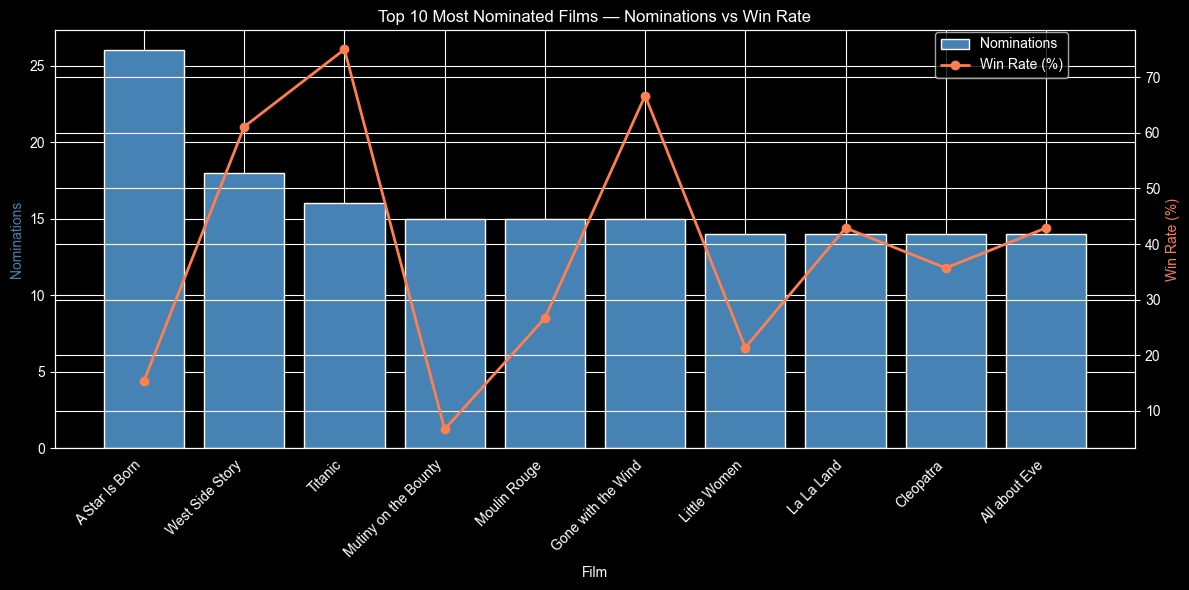

In [46]:
fig, ax1 = plt.subplots(figsize=(12, 6))

x = range(len(q8))

# Barras — nominations (eixo Y esquerdo)
ax1.bar(x, q8['nominations'], color='steelblue', label='Nominations')
ax1.set_xlabel('Film')
ax1.set_ylabel('Nominations', color='steelblue')
ax1.set_xticks(x)
ax1.set_xticklabels(q8['title'], rotation=45, ha='right')

ax2 = ax1.twinx()
ax2.plot(x, q8['win_rate_pct'], color='coral', marker='o', linewidth=2)
ax2.set_ylabel('Win Rate (%)', color='coral')

fig.legend(['Nominations', 'Win Rate (%)'], loc='upper right', bbox_to_anchor=(0.9, 0.95))

plt.title('Top 10 Most Nominated Films — Nominations vs Win Rate')
plt.tight_layout()
plt.show()

  1. Mais nomeações ≠ mais vitórias — A Star Is Born lidera com 26 nominations mas só 15.4% de win rate. Isto
  porque são nomeações acumuladas de 4 versões diferentes do filme (1937, 1954, 1976, 2018).
  2. Titanic é o mais eficiente — Com 16 nominations e 75% de win rate, é dos melhores desempenhos da história dos
  Oscars. Ganhou 11 de 16.
  3. Gone with the Wind e West Side Story — Ambos com win rates acima de 60%. São filmes de uma época onde havia
  menos competição por categoria.
  4. Mutiny on the Bounty é o oposto — 15 nominations e apenas 1 win (6.7%). O "maior perdedor" do top 10.
  5. Padrão geral — As barras (nominations) vão descendo da esquerda para a direita, mas a linha (win rate) sobe e
  desce sem seguir o mesmo padrão. Isso confirma visualmente que quantidade de nomeações e taxa de vitória são
  independentes.